In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import spikeinterface.full as si
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


si.set_global_job_kwargs(n_jobs=0.8, pool_engine='process')


In [3]:
from configuration import base_path, figure_folder
global_name = 'matching_drift_aware'
# dataset_name = 'Neuronexus-32_50_300.s'
# dataset_name = 'Neuropixels1-128_250_100.s'
# dataset_name = 'Neuropixels1-384_500_600.s'
dataset_name = 'Neuropixels1-384_500_1800.s'

motion_folder = base_path / global_name / dataset_name / 'motion'
study_folder = base_path / global_name / dataset_name / 'study'


In [4]:
from spikeinterface.benchmark.benchmark_matching import MatchingStudy
study = MatchingStudy(study_folder)
study

MatchingStudy study 
  datasets: 3 ['static', 'corrected', 'drifting']
  cases: 5 ['static_estimated', 'static_GT', 'corrected', 'drifting_interploated', 'drifting_GT']
  computed: 5

In [5]:
all_cases = list(study.cases.keys())

In [6]:
study.colors_by_case = {
    'static_estimated' : "#4B49B4",
    'static_GT' : "#B47D49",
    'drifting_interploated': "#6DB47C",
    'drifting_GT': "#A463B4",
    'corrected': "#E0D758",
}

# change labels to avoid re run
study.cases['static_estimated']['label'] = 'Static - Estimated templates '
study.cases['static_GT']['label'] = 'Static - True templates'
study.cases['drifting_interploated']['label'] = 'Templates interpolation'
study.cases['drifting_GT']['label'] = 'True drifting templates'
study.cases['corrected']['label'] = 'Traces interpolation'


(61, 2)
(61, 4, 135, 128)


/home/samuel.garcia/Documents/SpikeInterface/spikeinterface/src/spikeinterface/widgets/unit_waveforms.py:699: RuntimeWarning: divide by zero encountered in scalar divide
  y_scale = delta_y / m * 0.7


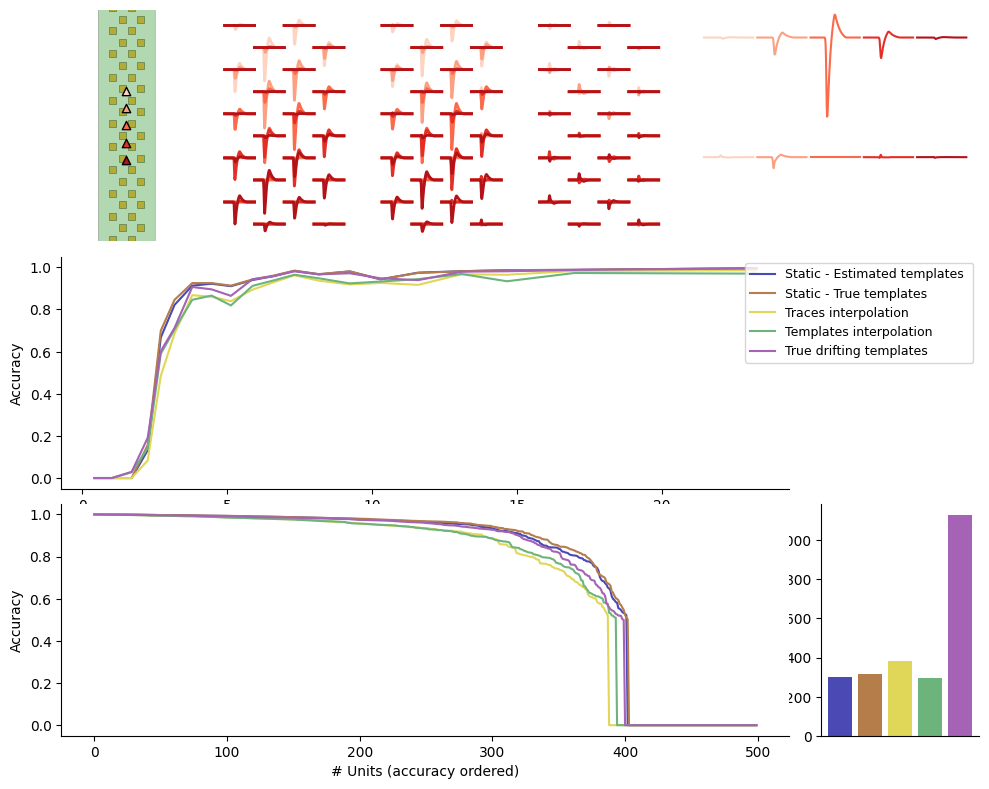

In [28]:
myparams = {
    'axes.titlesize' : 10,
    'axes.labelsize' : 10,
    'legend.fontsize': 9,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
}

import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from spikeinterface.benchmark.benchmark_plot_tools import despine, clean_axis, plot_study_legend, plot_performances_ordered
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


with mpl.rc_context(myparams):

    fig = plt.figure(figsize=(10, 8))
    gs = GridSpec(3, 1, figure=fig)
    gs0 = GridSpecFromSubplotSpec(2, 6, subplot_spec=gs[0, :])
    gs1 = GridSpecFromSubplotSpec(2, 5, subplot_spec=gs[1:, :])

    axs0 = [ fig.add_subplot(gs0[0:2,i]) for i in range(4)]
    axs0 += [fig.add_subplot(gs0[0:1,4:])]
    axs0 += [fig.add_subplot(gs0[1:2,4:])]



    ax1 = fig.add_subplot(gs1[0,:4])
    ax2 = fig.add_subplot(gs1[1, 4])
    ax3 = fig.add_subplot(gs1[0, 4])
    ax4 = fig.add_subplot(gs1[1, :4])

    plot_example_moving_templates(axs0)


    _ = study.plot_performances_vs_snr(case_keys=all_cases, performance_names=['accuracy'],
                                       metric_dataset_reference='static',
                                        with_sigmoid_fit=False,
                                        show_scatter=False,
                                        show_average_by_bin=True,
                                        show_legend=False, axs=[ax1])
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('SNR')

    _ = study.plot_run_times(case_keys=all_cases,ax=ax2)
    ax2.set_xticks([])
    ax2.set_xticklabels([])
    despine(ax2)

    plot_study_legend(study, case_keys=all_cases, ax=ax3)
    
    study.plot_performances_ordered(case_keys=all_cases, performance_names=['accuracy'],
                                    show_legend=False, axs=[ax4])

    ax4.set_title('')
    ax4.set_xlabel('# Units (accuracy ordered)')
    ax4.set_ylabel('Accuracy')


    fig.tight_layout(pad=1.1)
    fig.savefig(figure_folder / 'figure_drift.png')
    fig.savefig(figure_folder / 'figure_drift.pdf')



(61, 2)
(61, 4, 135, 128)


/home/samuel.garcia/Documents/SpikeInterface/spikeinterface/src/spikeinterface/widgets/unit_waveforms.py:699: RuntimeWarning: divide by zero encountered in scalar divide
  y_scale = delta_y / m * 0.7


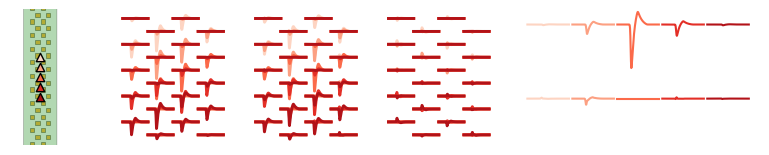

In [27]:
# %matplotlib widget
%matplotlib inline

from spikeinterface.benchmark.benchmark_plot_tools import despine, clean_axis
from spikeinterface.generation.drift_tools import DriftingTemplates
import scipy.spatial

def plot_example_moving_templates(axs):

    rec_static, rec_drifting, sorting, extra = si.generate_drifting_recording(
        extra_outputs=True, 
        num_units=4, 
        probe_name="Neuropixels1-128",
        generate_displacement_vector_kwargs=dict(
            displacement_sampling_frequency=5.0,
            drift_start_um=[0, 60],
            drift_stop_um=[0, -60],
            drift_step_um=2.,
            motion_list=[
                dict(
                    drift_mode="zigzag",
                    non_rigid_gradient=None,
                    t_start_drift=60.0,
                    t_end_drift=None,
                    period_s=200,
                ),
            ],
        ),
        generate_templates_kwargs=dict(
            ms_before=1.5,
            ms_after=3.0,
            # mode="ellipsoid",
            mode="ellipsoid",
            unit_params=dict(
                alpha=(150.0, 500.0),
                spatial_decay=(10, 45),
            ),
        ),
        seed=2205,
    )
    static_templates = extra['templates']
    unit_locations = extra['unit_locations']
    

    gt_drifting_templates = rec_drifting.drifting_templates
    displacements = gt_drifting_templates.displacements
    interp_drifting_templates = DriftingTemplates.from_static_templates(static_templates)
    interp_drifting_templates.precompute_displacements(displacements)
    

    static_templates = extra['templates']
    unit_locations = extra['unit_locations']
    

    num_disp = displacements.shape[0]
    print(displacements.shape)
    print(gt_drifting_templates.templates_array_moved.shape)

    
    sparsity_mask = scipy.spatial.distance.cdist(unit_locations[:, :2], static_templates.probe.contact_positions) < 100
    sparsity = si.ChannelSparsity(sparsity_mask, unit_ids=static_templates.unit_ids, channel_ids=rec_static.channel_ids)


    cell_id = 2

    chan_ind = 49

    # steps_indices = np.arange(0, num_disp, 10)
    # steps_indices [0, 10, 20, 30, 40, 50]
    steps_indices = [0, 15, 30, 45, 60]
    

    cmap = plt.colormaps["Reds"].resampled(len(steps_indices) + 2 )
    # cmap2 = plt.colormaps["Reds"].resampled(len(steps_indices))
    # cmap3 = plt.colormaps["Greens"].resampled(len(steps_indices))

    # fig, axes = plt.subplots(2,1, figsize=(15,5), sharex=True)

    ax0 = axs[0]
    si.plot_probe_map(rec_drifting, ax=ax0, with_channel_ids=False) # 
    loc = unit_locations[cell_id, :2]
    for i, step in enumerate(steps_indices):
        color = cmap(i + 1)
        ax0.scatter([loc[0] + displacements[step, 0]], [loc[1]+ displacements[step, 1]], color=color, marker='^', edgecolor='k')

    ax0.set_ylim(loc[1] - 200, loc[1] + 200)
    ax0.set_xlabel('')
    ax0.set_ylabel('')


    
    
    for i, step in enumerate(steps_indices):
        gt = gt_drifting_templates.templates_array_moved[step, cell_id, :, :][:, sparsity_mask[cell_id]].copy()
        interp = interp_drifting_templates.templates_array_moved[step, cell_id, :, :][:, sparsity_mask[cell_id]].copy()

        # axes[0].plot(gt.flatten(), c=cmap(i))
        # axes[0].plot(interp.flatten(), c=cmap2(i))
        # axes[1].plot((gt - interp).flatten(), c=cmap3(i))


        color = cmap(i + 1)

        def plot_one_template(a, ax):
            templates = extra['templates'].to_sparse(sparsity)
            templates.templates_array[cell_id, :, :gt.shape[1]] = a
            unit_ids = templates.unit_ids
            templates = templates.select_units(unit_ids[[cell_id]])
            si.plot_unit_templates(templates,
                                ax=ax, same_axis=True,
                                plot_legend=False,
                                abs_y_scale=1.3,
                                unit_colors = {unit_ids[cell_id] : color},
                                backend="matplotlib")
        plot_one_template(gt, axs[1])
        plot_one_template(interp, axs[2])
        plot_one_template(interp - gt, axs[3])

        # if i == 3:
        # chan_ind = 113
        # ax = axs[4]
        # gt = gt_drifting_templates.templates_array_moved[step, cell_id, :, chan_ind]
        # interp = interp_drifting_templates.templates_array_moved[step, cell_id, :, chan_ind]
        # ax.plot(gt, color=cmap(i))
        # # ax.plot(interp, color='black', ls='--')
        # ax.plot(interp - gt, color=cmap(i), ls='--')

        # if i == 4:

        # chan_ind = 79
        # ax = axs[5]
        # gt = gt_drifting_templates.templates_array_moved[step, cell_id, :, chan_ind]
        # interp = interp_drifting_templates.templates_array_moved[step, cell_id, :, chan_ind]
        # ax.plot(gt, color=cmap(i))
        # # ax.plot(interp, color='black', ls='--')
        # ax.plot(interp - gt, color=cmap(i), ls='--')

        # chan_ind = 113
        chan_ind = 81
        gt = gt_drifting_templates.templates_array_moved[step, cell_id, :, chan_ind]
        interp = interp_drifting_templates.templates_array_moved[step, cell_id, :, chan_ind]
        x = np.arange(gt.size) + (gt.size + 10) * i
        axs[4].plot(x, gt, color=color)
        # ax.plot(interp, color='black', ls='--')
        axs[5].plot(x, interp - gt, color=color) #, ls='--')


    
        

    for ax in axs:
        clean_axis(ax)
        ax.set_title('')
        ax.set_xlabel('')
        ax.set_ylabel('')
    
    ylim = axs[1].get_ylim()
    axs[2].set_ylim(*ylim)
    axs[3].set_ylim(*ylim)

    ylim = axs[4].get_ylim()
    axs[5].set_ylim(ylim)


    # fig, ax = plt.subplots()
    # si.plot_probe_map(rec_static, ax=ax)
    # ax.scatter(unit_locations[cell_id, 0], unit_locations[cell_id, 1])



fig = plt.figure(figsize=(10, 6))
gs = GridSpec(3, 1, figure=fig)
gs0 = GridSpecFromSubplotSpec(2, 6, subplot_spec=gs[0, :])
axs0 = [ fig.add_subplot(gs0[0:2,i]) for i in range(4)]
axs0 += [fig.add_subplot(gs0[0:1,4:])]
axs0 += [fig.add_subplot(gs0[1:2,4:])]

# fig, axs = plt.subplots(ncols=6, figsize=(10, 4))
plot_example_moving_templates(axs0)
